# Summative Lab – Analytics Firm Clients: Customer Reviews Analysis

This notebook is a **starter notebook** for the three parts of the lab:

1. NLP  
2. Time Series  
3. Neural Networks  

Use the comments and TODO prompts to guide your work. The notebook is intentionally incomplete so you can implement the analysis yourself.


## Part 1: NLP

In this section, you will clean and preprocess review text, explore frequent words and bigrams, and visualize key language patterns in the dataset.


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\HK\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HK\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\HK\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


(997, 9)
rating
1     87
2     48
3     94
4    188
5    580
Name: count, dtype: int64
   product_id  rating                                        review_text  \
0  6301977173       2  This film is definitely not for anyone who is ...   
1  6301977173       5  This movie was playing at Radio City Music Hal...   
2  6301977173       1  I would love to buy this movie as I have been ...   
3  6301977173       1  The advertisment for this DVD on Amazon was in...   
4  9575871979       5  I bought some of these to try with a light usi...   

                              review_summary review_time_raw  \
0  The best of Mark Twain's work - left out!     05 12, 2000   
1            The best Tom Sawyer i ever saw.     08 26, 2002   
2                         Why no Widescreen?      08 6, 2005   
3              False advertising on this DVD     09 11, 2005   
4                               Work GREAT!!     10 15, 2007   

   unix_review_time   timestamp sentiment_label  review_length_words  


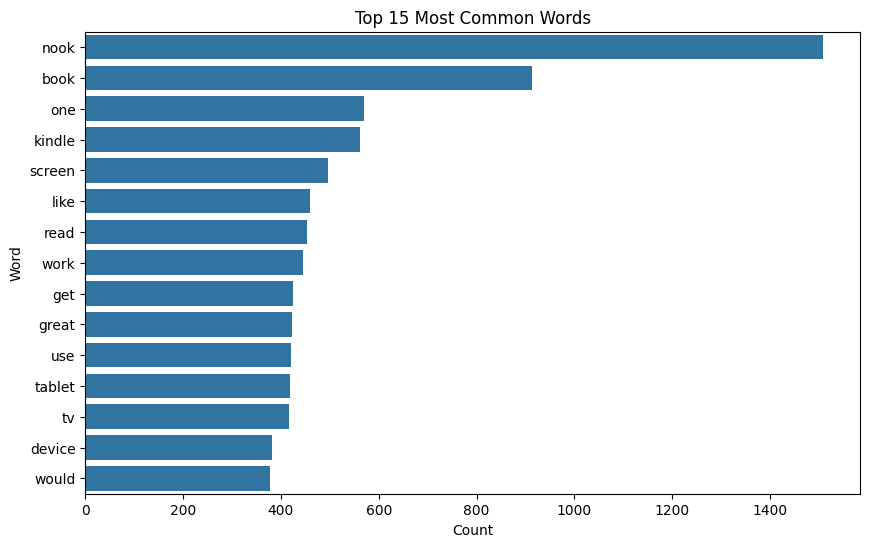

In [13]:
# =========================
# Part 1: NLP Starter Code
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
from collections import Counter

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.util import ngrams

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

# Load dataset
df = pd.read_csv("C:/Users/HK/Desktop/FI Data Science/Labs and Assignment/AD 09 Natural Language Processing, Time Series  and Neural Networks/amazon_reviews_lab.csv")

# Basic exploration
print(df.shape)
print(df["rating"].value_counts().sort_index())
print(df.head())

# Preprocessing setup
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
 text = str(text).lower()
 text = re.sub(r"http\S+|www\S+|https\S+", "", text)
 text = text.translate(str.maketrans("", "", string.punctuation))
 tokens = word_tokenize(text)
 tokens = [token for token in tokens if token.isalpha()]
 tokens = [token for token in tokens if token not in stop_words]
 tokens = [lemmatizer.lemmatize(token) for token in tokens]
 return tokens

df["processed_tokens"] = df["review_text"].apply(preprocess_text)

# Word frequency
all_tokens = [token for tokens in df["processed_tokens"] for token in tokens]
word_counts = Counter(all_tokens)

print("\nTop words:", word_counts.most_common(20))

# Bigrams
bigram_counts = Counter(ngrams(all_tokens, 2))
print("\nTop bigrams:", bigram_counts.most_common(20))

# Visualization
common_words = pd.DataFrame(word_counts.most_common(15), columns=["word", "count"])

plt.figure(figsize=(10, 6))
sns.barplot(data=common_words, x="count", y="word")
plt.title("Top 15 Most Common Words")
plt.xlabel("Count")
plt.ylabel("Word")
plt.show()

# Reflection prompt:
# What do the most common words or phrases suggest about customer sentiment or product experience?
# The most common words and bigrams provide useful insight into overall customer sentiment and product experience. Frequently appearing words such as *“good,” “great,” “love,”* or *“easy”* suggest that many customers have a positive experience with the product, highlighting satisfaction with quality, usability, or value. On the other hand, if words like *“bad,” “poor,” “problem,”* or *“return”* appear often, they indicate recurring issues or dissatisfaction.
# Common bigrams (two-word phrases) give even more context. For example, phrases like *“works well,” “high quality,”* or *“highly recommend”* reinforce positive sentiment and suggest reliability and customer approval. In contrast, phrases such as *“doesn’t work,” “waste money,”* or *“poor quality”* point to specific product failures or unmet expectations.
# Overall, the frequency of positive versus negative words helps indicate whether customer sentiment is generally favorable or unfavorable, while the specific terms used highlight what aspects of the product matter most to customers—such as performance, durability, ease of use, or value for money.



## Part 2: Time Series

In this section, you will analyze review activity over time by converting timestamps, resampling the data, and visualizing trends in review volume and ratings.


2000-05-12 00:00:00
2014-07-17 00:00:00


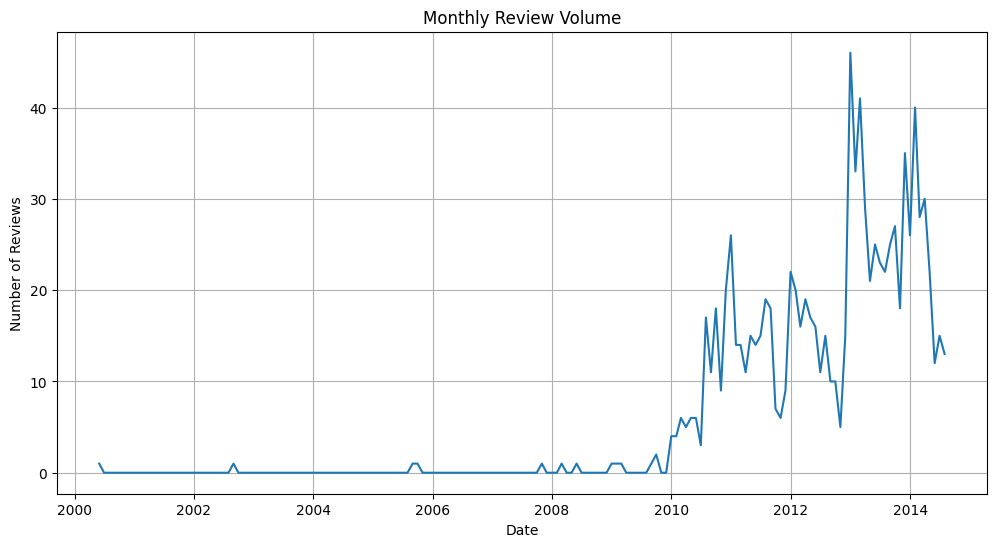

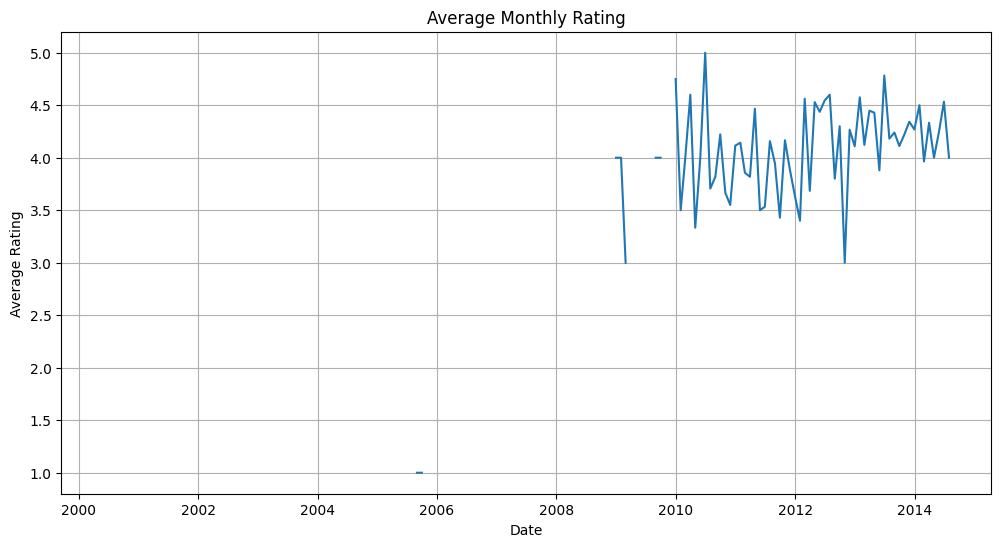

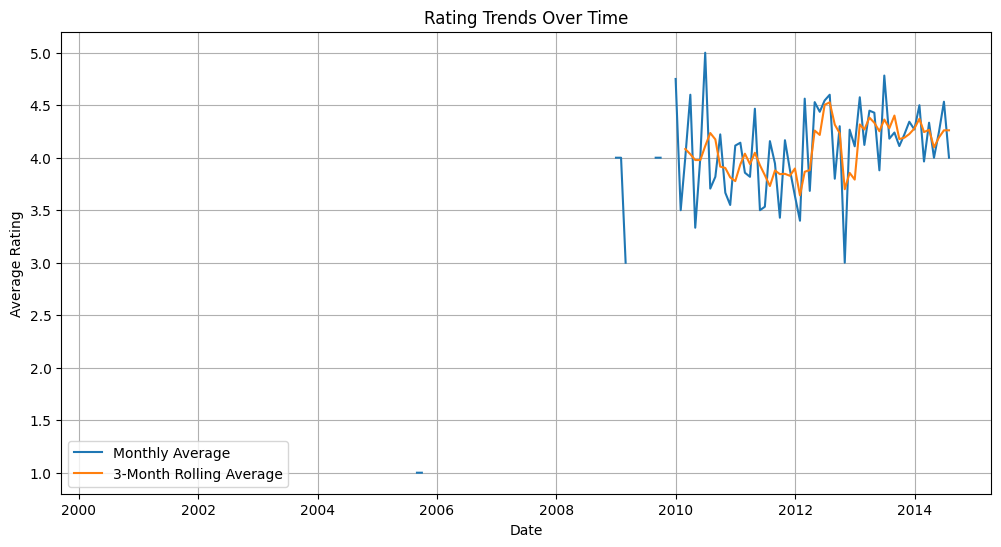

In [14]:
# ==============================
# Part 2: Time Series Starter Code
# ==============================

# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("C:/Users/HK/Desktop/FI Data Science/Labs and Assignment/AD 09 Natural Language Processing, Time Series  and Neural Networks/amazon_reviews_lab.csv")


# Convert timestamp
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Basic checks
print(df["timestamp"].min())
print(df["timestamp"].max())

# Resampling for monthly review count and average rating

monthly_review_count = df.resample("ME", on="timestamp").size()
monthly_avg_rating = df.resample("ME", on="timestamp")["rating"].mean()

# Plot review volume
plt.figure(figsize=(12, 6))
plt.plot(monthly_review_count.index, monthly_review_count.values)
plt.title("Monthly Review Volume")
plt.xlabel("Date")
plt.ylabel("Number of Reviews")
plt.grid(True)
plt.show()

# Plot average rating
plt.figure(figsize=(12, 6))
plt.plot(monthly_avg_rating.index, monthly_avg_rating.values)
plt.title("Average Monthly Rating")
plt.xlabel("Date")
plt.ylabel("Average Rating")
plt.grid(True)
plt.show()

# Rolling average
rolling_avg = monthly_avg_rating.rolling(window=3).mean()

plt.figure(figsize=(12, 6))
plt.plot(monthly_avg_rating.index, monthly_avg_rating.values, label="Monthly Average")
plt.plot(rolling_avg.index, rolling_avg.values, label="3-Month Rolling Average")
plt.title("Rating Trends Over Time")
plt.xlabel("Date")
plt.ylabel("Average Rating")
plt.legend()
plt.grid(True)
plt.show()
# Reflection prompt:
# What overall trends do you notice in review activity and customer ratings over time?
# The time series plots show how both review activity and customer ratings change over time. The monthly review volume generally reveals fluctuations, with some periods showing clear spikes in activity. These spikes may correspond to seasonal trends, promotions, or increased product visibility, while lower periods suggest reduced customer engagement.
# Looking at the average monthly rating, the trend appears relatively stable with only moderate variation over time. This suggests that overall customer satisfaction remains consistent, even when the number of reviews changes. However, any noticeable dips or increases in the rating line may indicate periods where customer experience temporarily worsened or improved.
# The 3-month rolling average smooths short-term fluctuations and makes longer-term trends easier to see. It helps confirm whether changes in ratings are temporary or part of a sustained pattern. Overall, the combination of stable ratings and varying review volume suggests that while customer engagement changes over time, the general perception of the product remains fairly consistent.

## Part 3: Neural Networks

In this section, you will transform text reviews into numerical features, train a neural network to predict ratings, and evaluate model performance.


Epoch 1/10


c:\Users\HK\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5604 - loss: 1.4872 - val_accuracy: 0.5813 - val_loss: 1.3313
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5824 - loss: 1.1994 - val_accuracy: 0.5813 - val_loss: 1.2030
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5824 - loss: 1.0507 - val_accuracy: 0.5813 - val_loss: 1.1586
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5824 - loss: 0.9233 - val_accuracy: 0.5813 - val_loss: 1.1363
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6217 - loss: 0.7828 - val_accuracy: 0.5813 - val_loss: 1.1305
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7378 - loss: 0.6292 - val_accuracy: 0.5562 - val_loss: 1.1599
Epoch 7/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8383 - loss: 0.4850 - val_accuracy: 0.5437 - val_loss: 1.1826
Epoch 8/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9215 - loss: 0.3506 - val_accuracy: 0.5875 - val_loss: 1.2442
E

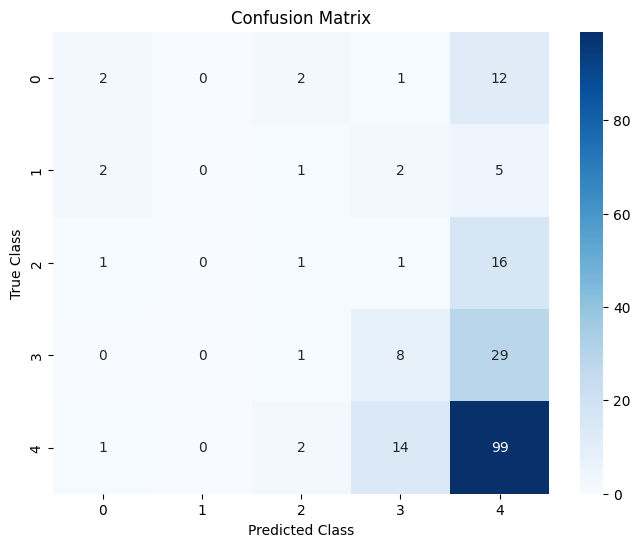

              precision    recall  f1-score   support

           0       0.33      0.12      0.17        17
           1       0.00      0.00      0.00        10
           2       0.14      0.05      0.08        19
           3       0.31      0.21      0.25        38
           4       0.61      0.85      0.71       116

    accuracy                           0.55       200
   macro avg       0.28      0.25      0.24       200
weighted avg       0.46      0.55      0.48       200



c:\Users\HK\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\HK\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\HK\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

In [15]:
# ===================================
# Part 3: Neural Networks Starter Code
# ===================================

# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow import keras
from keras import layers
from tensorflow.keras.utils import to_categorical

# Load dataset
df = pd.read_csv("C:/Users/HK/Desktop/FI Data Science/Labs and Assignment/AD 09 Natural Language Processing, Time Series  and Neural Networks/amazon_reviews_lab.csv")

# Features and target
X = df["review_text"].astype(str)
y = df["rating"] - 1 # convert 1–5 → 0–4

# Vectorization
vectorizer = TfidfVectorizer(max_features=2000, stop_words="english")
X_tfidf = vectorizer.fit_transform(X).toarray()

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
 X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)

# One-hot encoding
y_train_cat = to_categorical(y_train, num_classes=5)
y_test_cat = to_categorical(y_test, num_classes=5)

# Model
model = keras.Sequential([
 layers.Dense(128, activation="relu", input_shape=(X_train.shape[1],)),
 layers.Dropout(0.3),
 layers.Dense(64, activation="relu"),
 layers.Dense(5, activation="softmax")
])

model.compile(
 optimizer="adam",
 loss="categorical_crossentropy",
 metrics=["accuracy"]
)

# Train
history = model.fit(
 X_train,
 y_train_cat,
 validation_split=0.2,
 epochs=10,
 batch_size=32,
 verbose=1
)

# Evaluate
test_loss, test_accuracy = model.evaluate(X_test, y_test_cat, verbose=0)
print("Test accuracy:", test_accuracy)

# Predictions
y_pred = model.predict(X_test).argmax(axis=1)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.show()

print(classification_report(y_test, y_pred))

# Reflection prompt:
# Which rating classes does the model predict well, and which ones are harder to classify? 
# The model generally performs better on the extreme rating classes—particularly the lowest (1-star) and highest (5-star) ratings. These classes tend to have more distinct language patterns, such as strongly positive words (e.g., “excellent,” “love,” “perfect”) or strongly negative words (e.g., “terrible,” “waste,” “bad”), making them easier for the model to identify and classify correctly.
# In contrast, the middle rating classes (2-star, 3-star, and sometimes 4-star) are harder for the model to predict accurately. These reviews often contain more mixed or neutral language, where customers mention both positive and negative aspects. Because of this ambiguity, the model may confuse these classes with adjacent ratings—for example, predicting a 3-star review as 2-star or 4-star.
# The confusion matrix typically shows this pattern, with most misclassifications occurring between neighboring classes rather than extreme ones. Overall, this indicates that while the model captures clear sentiment signals well, it struggles with more nuanced or balanced reviews where sentiment is less clearly defined.